# RQ1: Which factors are the strongest predictors of calories burned during a workout?
**INFO-B 211: Information Infrastructure II**  
**Fitness Tracker Data Analysis**

---
**Dataset:** Calorie Burnt 15k — real exercise session records for ~15,000 users  
**Source:** HuggingFace (`raw_exercise.csv` + `raw_calories.csv`, merged on `User_ID`)

**Method:**
- Merge exercise and calorie datasets on `User_ID`
- Train Linear Regression and Decision Tree Regression models
- Compare feature importance / coefficients for key variables
- Evaluate model performance using R² and MSE

## Step 1: Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


## Step 2: Load & Merge Data

In [4]:
exercise = pd.read_csv('raw_exercise.csv')
calories = pd.read_csv('raw_calories.csv')

print('Exercise shape:', exercise.shape)
print('Calories shape:', calories.shape)
print()
print('Exercise preview:')
display(exercise.head())
print('Calories preview:')
display(calories.head())

Exercise shape: (15000, 8)
Calories shape: (15000, 2)

Exercise preview:


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


Calories preview:


,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [5]:
# Merge both files on User_ID
df = pd.merge(exercise, calories, on='User_ID')

print('Merged shape:', df.shape)
print('Missing values:')
print(df.isnull().sum())
df.head()

Merged shape: (15000, 9)
Missing values:
User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [4]:
# Summary statistics
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


## Step 3: Prepare Features & Target

In [6]:
# Encode Gender (male=1, female=0)
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])
print('Gender mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

feature_cols = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Gender_Encoded']

X = df[feature_cols]
y = df['Calories']

print('\nFeatures shape:', X.shape)
print('Any NaN in X:', X.isnull().any().any())
print('Any NaN in y:', y.isnull().any())

Gender mapping: {'female': 0, 'male': 1}

Features shape: (15000, 7)
Any NaN in X: False
Any NaN in y: False


In [7]:
# Correlation of each feature with Calories — preview before modeling
corrs = X.corrwith(y).sort_values(ascending=False)
print('Pearson correlations with Calories:')
print(corrs.round(4))

Pearson correlations with Calories:
Duration          0.9554
Heart_Rate        0.8979
Body_Temp         0.8246
Age               0.1544
Weight            0.0355
Gender_Encoded    0.0224
Height            0.0175
dtype: float64


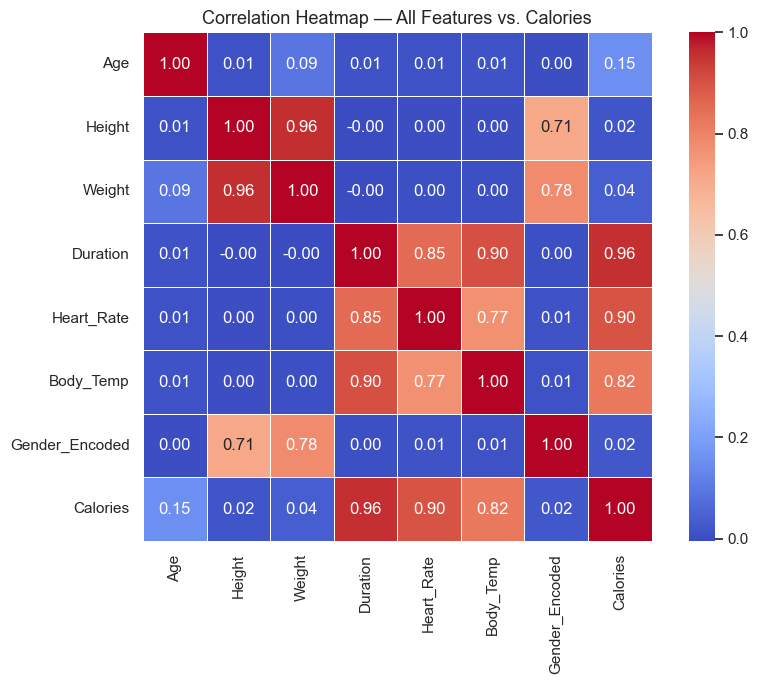

In [8]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[feature_cols + ['Calories']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True, ax=ax)
ax.set_title('Correlation Heatmap — All Features vs. Calories', fontsize=13)
plt.tight_layout()
plt.savefig('rq1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Training samples:', len(X_train))
print('Testing samples: ', len(X_test))

Training samples: 12000
Testing samples:  3000


## Step 4: Train Models

In [10]:
# --- Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr  = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)

print('Linear Regression')
print(f'  R²:  {r2_lr:.4f}')
print(f'  MSE: {mse_lr:.2f}')

Linear Regression
  R²:  0.9673
  MSE: 132.00


In [11]:
# --- Decision Tree Regressor ---
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

r2_dt  = r2_score(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)

print('Decision Tree Regressor')
print(f'  R²:  {r2_dt:.4f}')
print(f'  MSE: {mse_dt:.2f}')

Decision Tree Regressor
  R²:  0.9616
  MSE: 154.88


## Step 5: Model Performance Comparison

In [12]:
# Summary table
performance = pd.DataFrame({
    'Model':  ['Linear Regression', 'Decision Tree'],
    'R²':     [round(r2_lr, 4),  round(r2_dt, 4)],
    'MSE':    [round(mse_lr, 2), round(mse_dt, 2)],
    'RMSE':   [round(np.sqrt(mse_lr), 2), round(np.sqrt(mse_dt), 2)]
})
print(performance.to_string(index=False))

            Model     R²    MSE  RMSE
Linear Regression 0.9673 132.00 11.49
    Decision Tree 0.9616 154.88 12.45


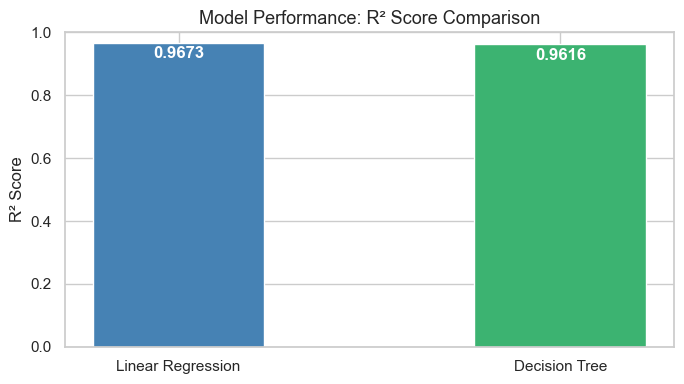

In [13]:
# R² comparison bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Linear Regression', 'Decision Tree'],
              [r2_lr, r2_dt],
              color=['steelblue', 'mediumseagreen'],
              edgecolor='white', width=0.45)
ax.set_ylim(0, 1)
ax.set_title('Model Performance: R² Score Comparison', fontsize=13)
ax.set_ylabel('R² Score')

for bar, val in zip(bars, [r2_lr, r2_dt]):
    ax.text(bar.get_x() + bar.get_width()/2, val - 0.05,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('rq1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Feature Importance — Decision Tree

In [14]:
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)

print('Feature Importances (Decision Tree):')
print(importances.round(4).to_string())

Feature Importances (Decision Tree):
Duration          0.9403
Heart_Rate        0.0381
Age               0.0188
Gender_Encoded    0.0028
Height            0.0000
Weight            0.0000
Body_Temp         0.0000


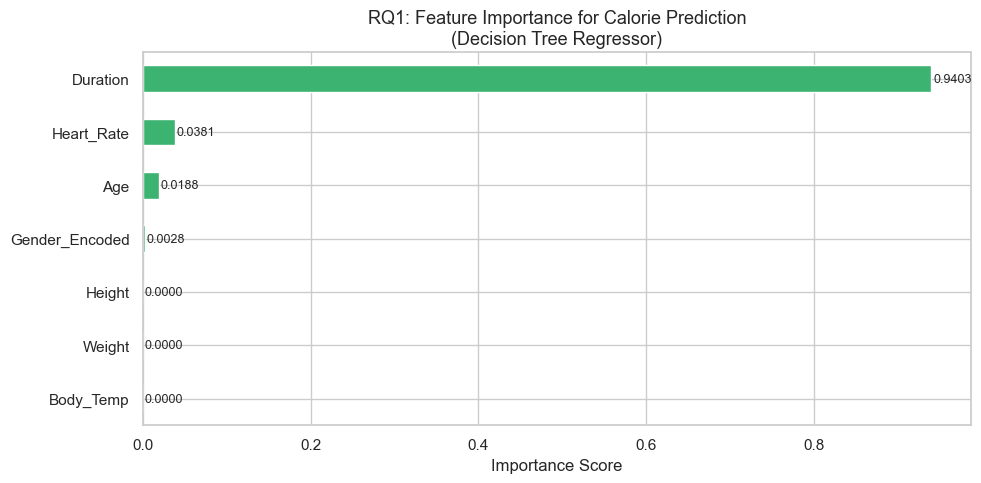

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
importances.plot(kind='barh', color='mediumseagreen', ax=ax, edgecolor='white')
ax.set_title('RQ1: Feature Importance for Calorie Prediction\n(Decision Tree Regressor)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.invert_yaxis()

for i, val in enumerate(importances):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('rq1_feature_importance_dt.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Feature Coefficients — Linear Regression

In [16]:
coef_df = pd.DataFrame({
    'Feature':     feature_cols,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Linear Regression Coefficients (sorted by magnitude):')
print(coef_df.round(4).to_string(index=False))

Linear Regression Coefficients (sorted by magnitude):
       Feature  Coefficient
     Body_Temp     -16.9425
      Duration       6.6280
    Heart_Rate       1.9909
Gender_Encoded      -1.3742
           Age       0.5015
        Weight       0.2863
        Height      -0.1697


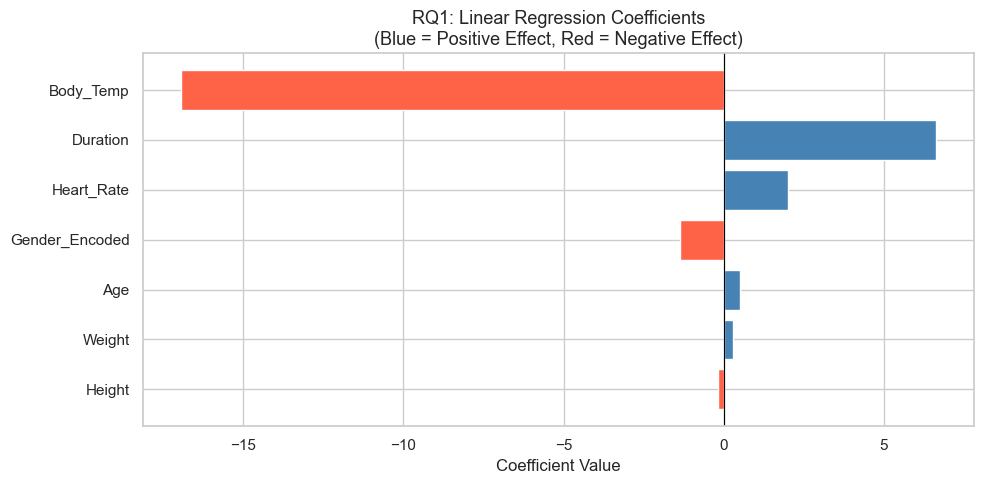

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if c >= 0 else 'tomato' for c in coef_df['Coefficient']]

ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('RQ1: Linear Regression Coefficients\n(Blue = Positive Effect, Red = Negative Effect)', fontsize=13)
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('rq1_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Top Predictor Deep Dive — Duration vs. Calories

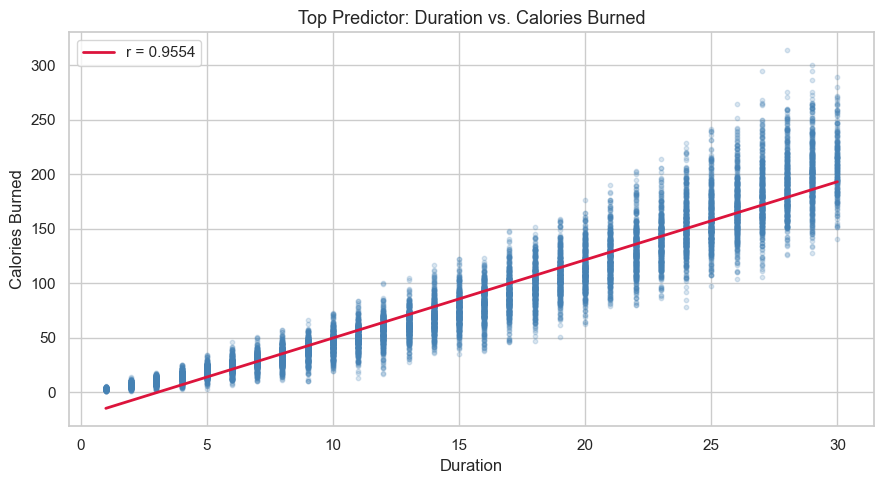

In [18]:
# Scatter plot of the strongest predictor
top_feature = importances.index[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df[top_feature], df['Calories'], alpha=0.2, s=10, color='steelblue')

m, b = np.polyfit(df[top_feature], df['Calories'], 1)
x_line = np.linspace(df[top_feature].min(), df[top_feature].max(), 200)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2,
        label=f'r = {df[[top_feature, "Calories"]].corr().iloc[0,1]:.4f}')

ax.set_title(f'Top Predictor: {top_feature} vs. Calories Burned', fontsize=13)
ax.set_xlabel(top_feature)
ax.set_ylabel('Calories Burned')
ax.legend()
plt.tight_layout()
plt.savefig('rq1_top_predictor_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Summary

In [19]:
top3 = importances.head(3).index.tolist()
winner = 'Decision Tree' if r2_dt > r2_lr else 'Linear Regression'

print('=' * 60)
print('RQ1 SUMMARY: Strongest Predictors of Calories Burned')
print('=' * 60)
print(f'''
Dataset: 15,000 real exercise session records

Model Performance:
  Linear Regression  → R²: {r2_lr:.4f}, MSE: {mse_lr:.2f}
  Decision Tree      → R²: {r2_dt:.4f}, MSE: {mse_dt:.2f}
  Better model: {winner}

Top 3 Predictors (Decision Tree Feature Importance):
  1. {top3[0]}
  2. {top3[1]}
  3. {top3[2]}

Conclusion:
  Both models achieve high predictive accuracy (R² > 0.96),
  confirming that calorie burn can be reliably predicted from
  biometric and exercise data. {top3[0]} and {top3[1]}
  are by far the strongest drivers, suggesting that workout
  behavior and physiological intensity matter more than
  demographic factors like age or weight alone.
''')

RQ1 SUMMARY: Strongest Predictors of Calories Burned

Dataset: 15,000 real exercise session records

Model Performance:
  Linear Regression  → R²: 0.9673, MSE: 132.00
  Decision Tree      → R²: 0.9616, MSE: 154.88
  Better model: Linear Regression

Top 3 Predictors (Decision Tree Feature Importance):
  1. Duration
  2. Heart_Rate
  3. Age

Conclusion:
  Both models achieve high predictive accuracy (R² > 0.96),
  confirming that calorie burn can be reliably predicted from
  biometric and exercise data. Duration and Heart_Rate
  are by far the strongest drivers, suggesting that workout
  behavior and physiological intensity matter more than
  demographic factors like age or weight alone.



In [20]:
def performance_label(r2):
    if r2 >= 0.9:
        return "Very Strong"
    elif r2 >= 0.8:
        return "Strong"
    elif r2 >= 0.6:
        return "Moderate"
    else:
        return "Weak"

print("\nPerformance Evaluation:")
print(f"Linear Regression: {performance_label(r2_lr)} predictive performance")
print(f"Decision Tree: {performance_label(r2_dt)} predictive performance")


Performance Evaluation:
Linear Regression: Very Strong predictive performance
Decision Tree: Very Strong predictive performance
